In [39]:
# ==========================================
# Titanic Survival Prediction
# ==========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [40]:
# ==========================================
# Step 2: Load Dataset
# ==========================================

df = pd.read_csv("data/train.csv")

print(df.head())

print(df.info())

print(df.describe())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [41]:
# ==========================================
# Step 3: Check Missing Values
# ==========================================

print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [42]:

# ==========================================
# Step 4: Handle Missing Values
# ==========================================

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Cabin"] = df["Cabin"].fillna("Unknown")


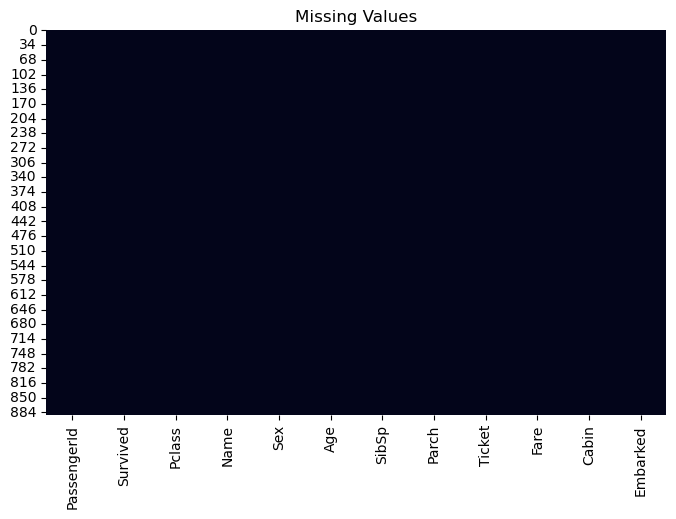

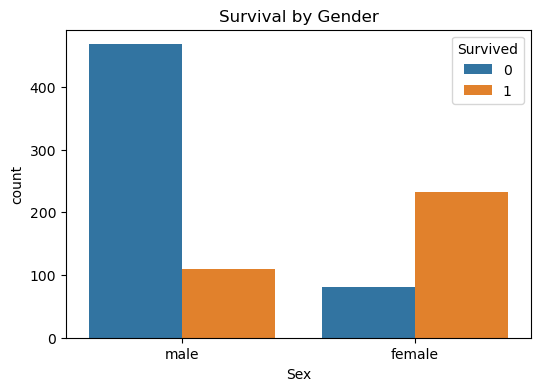

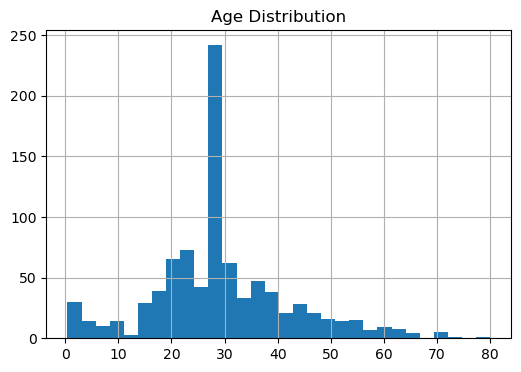

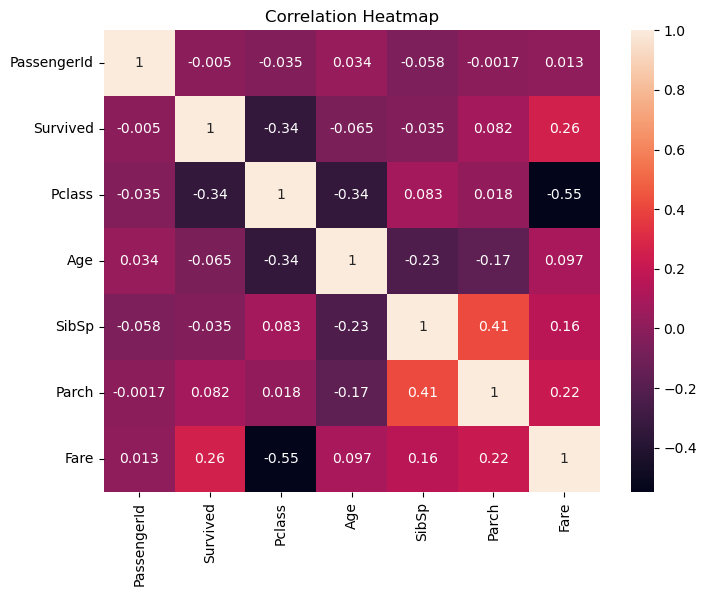

In [43]:

# ==========================================
# Step 5: Exploratory Data Analysis
# ==========================================

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

plt.figure(figsize=(6,4))
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [44]:


# ==========================================
# Step 6: Feature Engineering
# ==========================================

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

df["Cabin"] = encoder.fit_transform(df["Cabin"])


In [45]:
# ==========================================
# Step 7: Drop Unnecessary Columns
# ==========================================

df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)


In [46]:
print(df.dtypes)

Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin         int64
Embarked      int64
dtype: object


In [47]:

# ==========================================
# Step 8: Prepare Features and Target
# ==========================================

X = df.drop("Survived", axis=1)

y = df["Survived"]


In [48]:
print(df.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Cabin  Embarked
0         0       3    1  22.0      1      0   7.2500    147         2
1         1       1    0  38.0      1      0  71.2833     81         0
2         1       3    0  26.0      0      0   7.9250    147         2
3         1       1    0  35.0      1      0  53.1000     55         2
4         0       3    1  35.0      0      0   8.0500    147         2


In [49]:

# ==========================================
# Step 9: Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
# ==========================================
# Step 10: Build Model
# ==========================================

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:

# ==========================================
# Step 11: Prediction
# ==========================================

pred = model.predict(X_test)



In [53]:
# ==========================================
# Step 12: Evaluation
# ==========================================

print("Accuracy :", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))


Accuracy : 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

[[90 15]
 [20 54]]


    Feature  Importance
1       Sex    0.260275
5      Fare    0.238654
2       Age    0.226400
6     Cabin    0.089615
0    Pclass    0.068577
3     SibSp    0.047319
4     Parch    0.036429
7  Embarked    0.032730


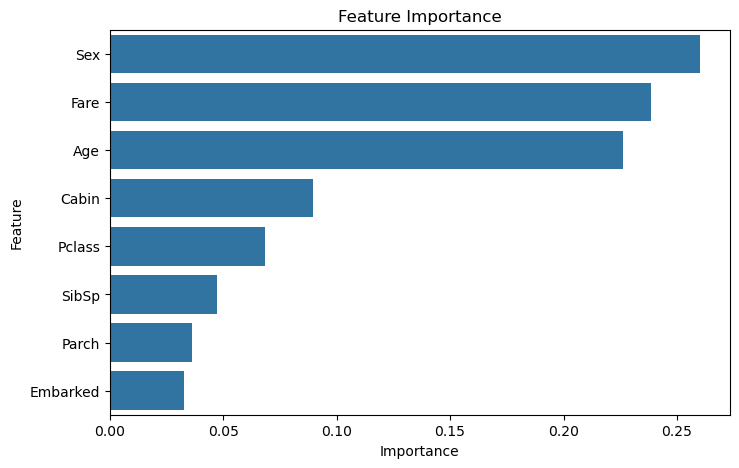

In [54]:





# ==========================================
# Step 13: Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [56]:
# ==========================================
# Step 14: Save Model
# ==========================================

import joblib

joblib.dump(model, "random_forest_model.pkl")

print("Model Saved Successfully")



Model Saved Successfully


In [57]:
# ==========================================
# Step 15: Predict New Passenger
# ==========================================

new_passenger = pd.DataFrame({
    "Pclass":[3],
    "Sex":[1],
    "Age":[22],
    "SibSp":[1],
    "Parch":[0],
    "Fare":[7.25],
    "Cabin":[0],
    "Embarked":[2]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Did Not Survive
